In [ ]:
import numpy as np
import pyccl as ccl
import healpy as hp
from tqdm import tqdm
from astropy import units as u
from matplotlib import pyplot as plt


In [2]:
import sys, os
sys.path.append('/home/yshi/work/work_gravity/akra_series_local/utils/')
from gaussianfield import get_cl
sys.path.append('/home/yshi/work/work_gravity/akra_series_local/core/')
from hpplot import mollview


In [3]:
# NOTE: This notebook was run with nside = 128 on a server with 376 GB of RAM.
# For AKRA 2.0 tests, start with the baseline resolution nside = 16.
# AKRA 3.0 can generally run at nside = 128, 256, or 512 on most computing systems.
### Generate gamma1, gamma2 maps from convergence map using healpy
np.random.seed(12)
nside = 128
lmax = int(nside*1.5)
nside_out = nside

from akra_full import sph_kappa2gamma

l = np.arange(lmax)
cls = get_cl(ell=l)
cls[0] = 0.0
cls[1] = 0.0
### because the spin is 2, the first two multipoles are zero
alm_kappa = hp.synalm(cls)
kappa0 = hp.alm2map(alm_kappa, nside=nside_out)
gamma10, gamma20 = sph_kappa2gamma(kappa0, nside_out, lmax=lmax)

/home/yshi/.conda/envs/mypy310/lib/python3.10/site-packages/pyccl/tracers.py:150: CCLWarning: The number of samples in the n(z) (200) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False before instantiating the Cosmology passed.
  warnings.warn(
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:37: RuntimeWarning: divide by zero encountered in divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:37: RuntimeWarning: invalid value encountered in divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)


/tmp/ipykernel_356875/4018015481.py:5: RuntimeWarning: divide by zero encountered in power
  cl_sel = l**-1.5
/home/yshi/.conda/envs/mypy310/lib/python3.10/site-packages/healpy/visufunc.py:356: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pylab.draw()
/home/yshi/.conda/envs/mypy310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


mask percent: 0.4405


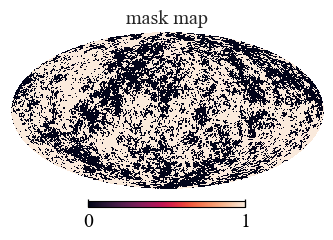

In [4]:
### Random Generate mask map 
lmax_mask = lmax
l = np.arange(lmax_mask)
cl_sel = np.ones_like(l) 
cl_sel = l**-1.5
cl_sel[0] = 0
# plt.semilogx(cl_sel)
sel = hp.synfast(cl_sel, nside_out)
sel = np.tanh(sel/sel.std()/3.0) + 1.0
sel = sel/sel.max()
mask = np.zeros_like(sel)
th = 0.5
mask[sel>th] = 1
mask[sel<=th] = 0
hp.mollview(mask, sub=(2,2,1), title='mask map')
mask_percent = 1-np.sum(mask==1)/len(mask)
print("mask percent: %.4f"%(mask_percent))

In [ ]:
# np.savez("/home/yshi/work/work_gravity/akra_series_local/akra_spere/test_data.npz", gamma10=gamma10, gamma20=gamma20, mask=mask, lmax=lmax, nside=nside_out, kappa0=kappa0)

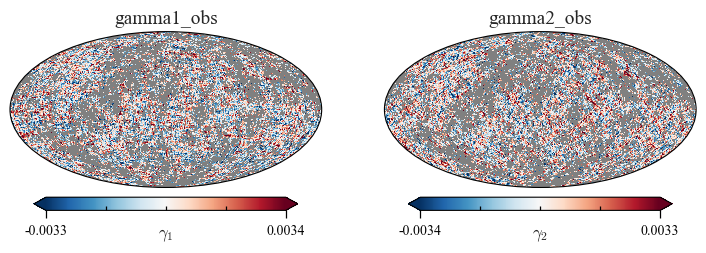

In [6]:
### Generate observed shear maps
gamma1_obs = gamma10 * mask
gamma2_obs = gamma20 * mask

########## Note: Pay attention there may be -1*gamma1/gamma2 difference in different coordinate conventions 
########### Plot observed shear maps (gray pixels are masked)
mollview(gamma1_obs, sub=(1,2,1), title='gamma1_obs', unit="$\gamma_1$", unseen=True)
mollview(gamma2_obs, sub=(1,2,2), title='gamma2_obs', unit="$\gamma_2$", unseen=True)



## You can test AKRA 2.0 (direct) from this panel

In [7]:
from akra_full import KappaRec_sphere
kappa_rec = KappaRec_sphere(gamma1_obs, gamma2_obs, mask, lmax=lmax, choSolve=True)
kappa_rec.sphere_AKRA(nosh=True) ## nosh=True means ((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5 factor is included in the reconstruction
akra2_map = kappa_rec.kappa_akra

Observed yy shape:  (2, 37249)
Calculating A^T A...


  0%|          | 0/18721 [00:00<?, ?it/s]

100%|██████████| 18721/18721 [05:18<00:00, 58.82it/s]


Time used:  385.39467668533325 s
The shape of A is:  (74498, 37249)
18721


100%|██████████| 18721/18721 [00:00<00:00, 64175.72it/s]
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:353: RuntimeWarning: divide by zero encountered in divide
  alm_kappar = 1*alm_kappar*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:353: RuntimeWarning: invalid value encountered in multiply
  alm_kappar = 1*alm_kappar*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:354: RuntimeWarning: divide by zero encountered in divide
  alm_kappai = 1*alm_kappai*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:354: RuntimeWarning: invalid value encountered in multiply
  alm_kappai = 1*alm_kappai*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5


## You can test AKRA 3.0 from this panel

In [8]:
from akra_full_cg import KappaRec_sphere_fast
kappa_rec = KappaRec_sphere_fast(gamma1_obs, gamma2_obs, mask, lmax=lmax)
kappa_rec.sphere_AKRA() ## nosh=True means ((ell
akra3_map = kappa_rec.kappa_akra

/home/yshi/work/work_gravity/akra_series_local/core/akra_full_cg.py:231: RuntimeWarning: divide by zero encountered in divide
  factor = (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1.))) ** 0.5)


KappaRec_sphere_fast initialized:
  lmax = 192
  nside = 128
  n_cols = 37249
  Observed yy shape: (74498,)
  Explicit matrix would be: 44.40 GB
Computing A^H @ y via SHT...
  Time: 0.03s
Solving (A^H A + λI) x = A^H y with matrix-free CG...
lam used without scaling:  0.001
Solving with matrix-free CG...
CG finished: 19 iterations, info=0
  Total solve time: 4.63s


## KS results

In [9]:
from akra_full import sph_gamma2kappa
ks_map, kappa_ks_B = sph_gamma2kappa(gamma1_obs, gamma2_obs, nside, lmax=lmax, return_B=True)

/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:56: RuntimeWarning: divide by zero encountered in divide
  alm_E = alm_E * (((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5)
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:56: RuntimeWarning: invalid value encountered in multiply
  alm_E = alm_E * (((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5)


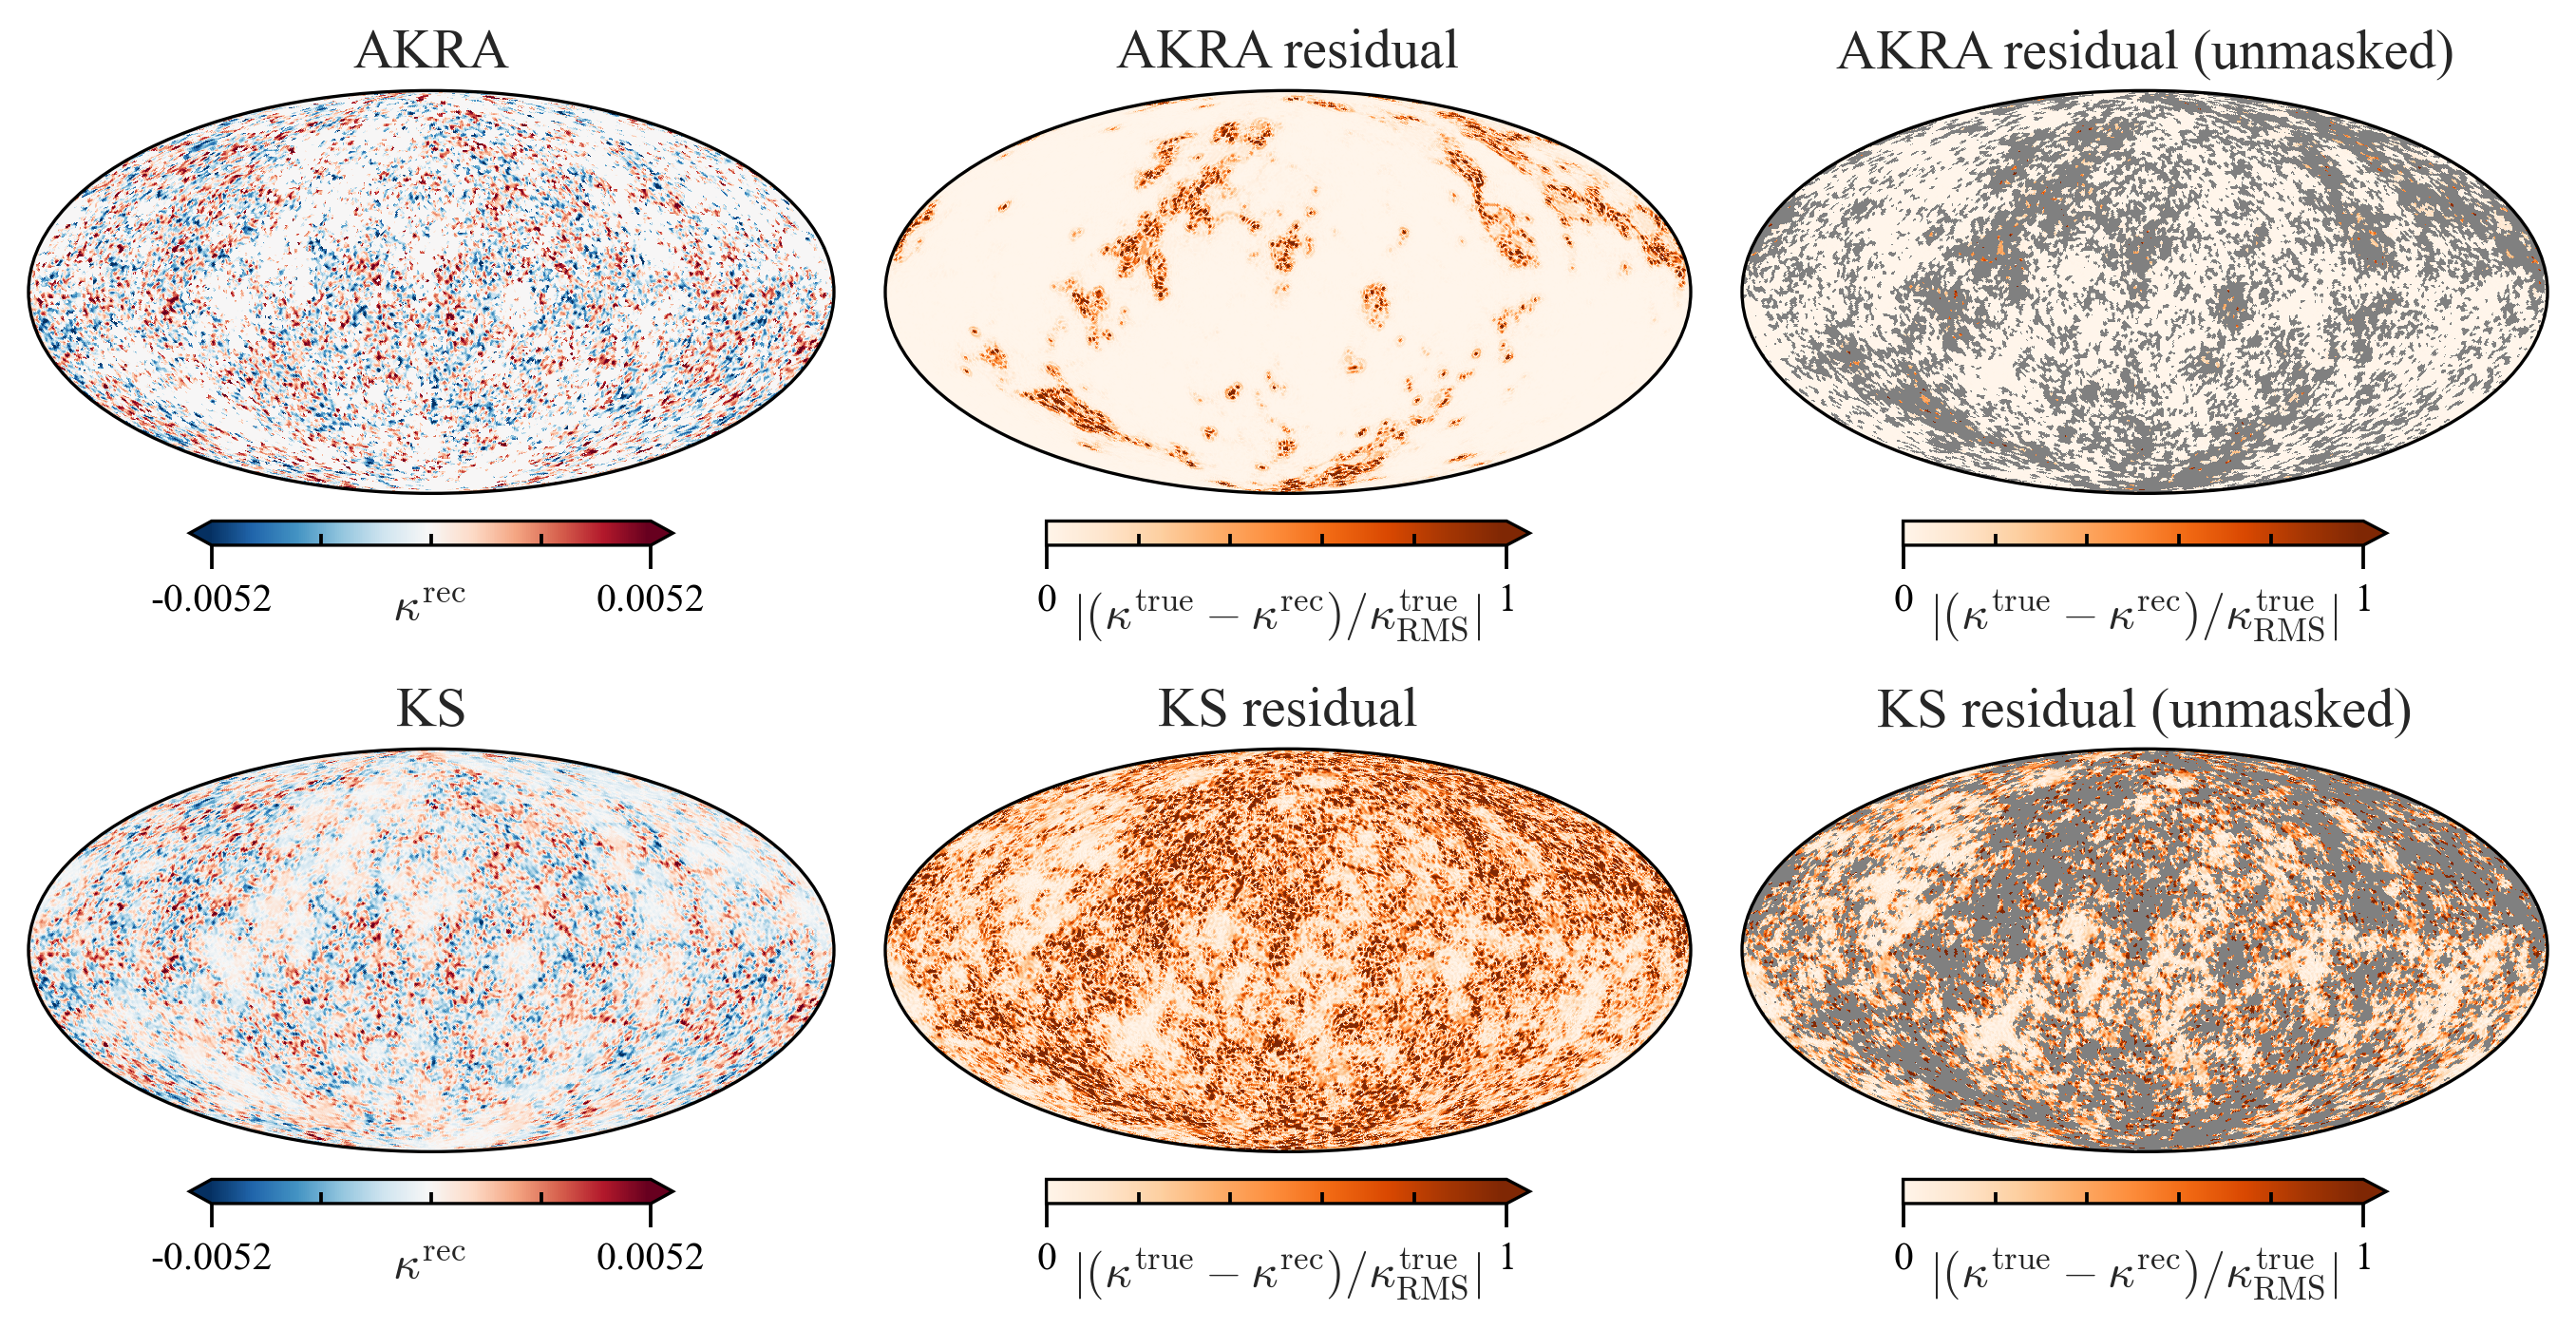

In [10]:
#### Results from AKRA 2.0 and KS methods
plt.figure(figsize=(9.2,4.8), dpi=300)
vmin = -0.0052
vmax = 0.0052

akra_map = akra2_map
mollview(akra_map*mask, sub=231, title="AKRA", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(akra_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=232, vmin=0, vmax=1, title="AKRA residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(akra_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=233, vmin=0, vmax=1, title="AKRA residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)

mollview(ks_map, sub=234, title="KS", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(ks_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=235, vmin=0, vmax=1, title="KS residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(ks_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=236, vmin=0, vmax=1, title="KS residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)
# plt.subplots_adjust(hspace=0.01)
# plt.savefig(figDir + "random_g1g2Mask-results.pdf", bbox_inches='tight', transparent=True)
plt.show()

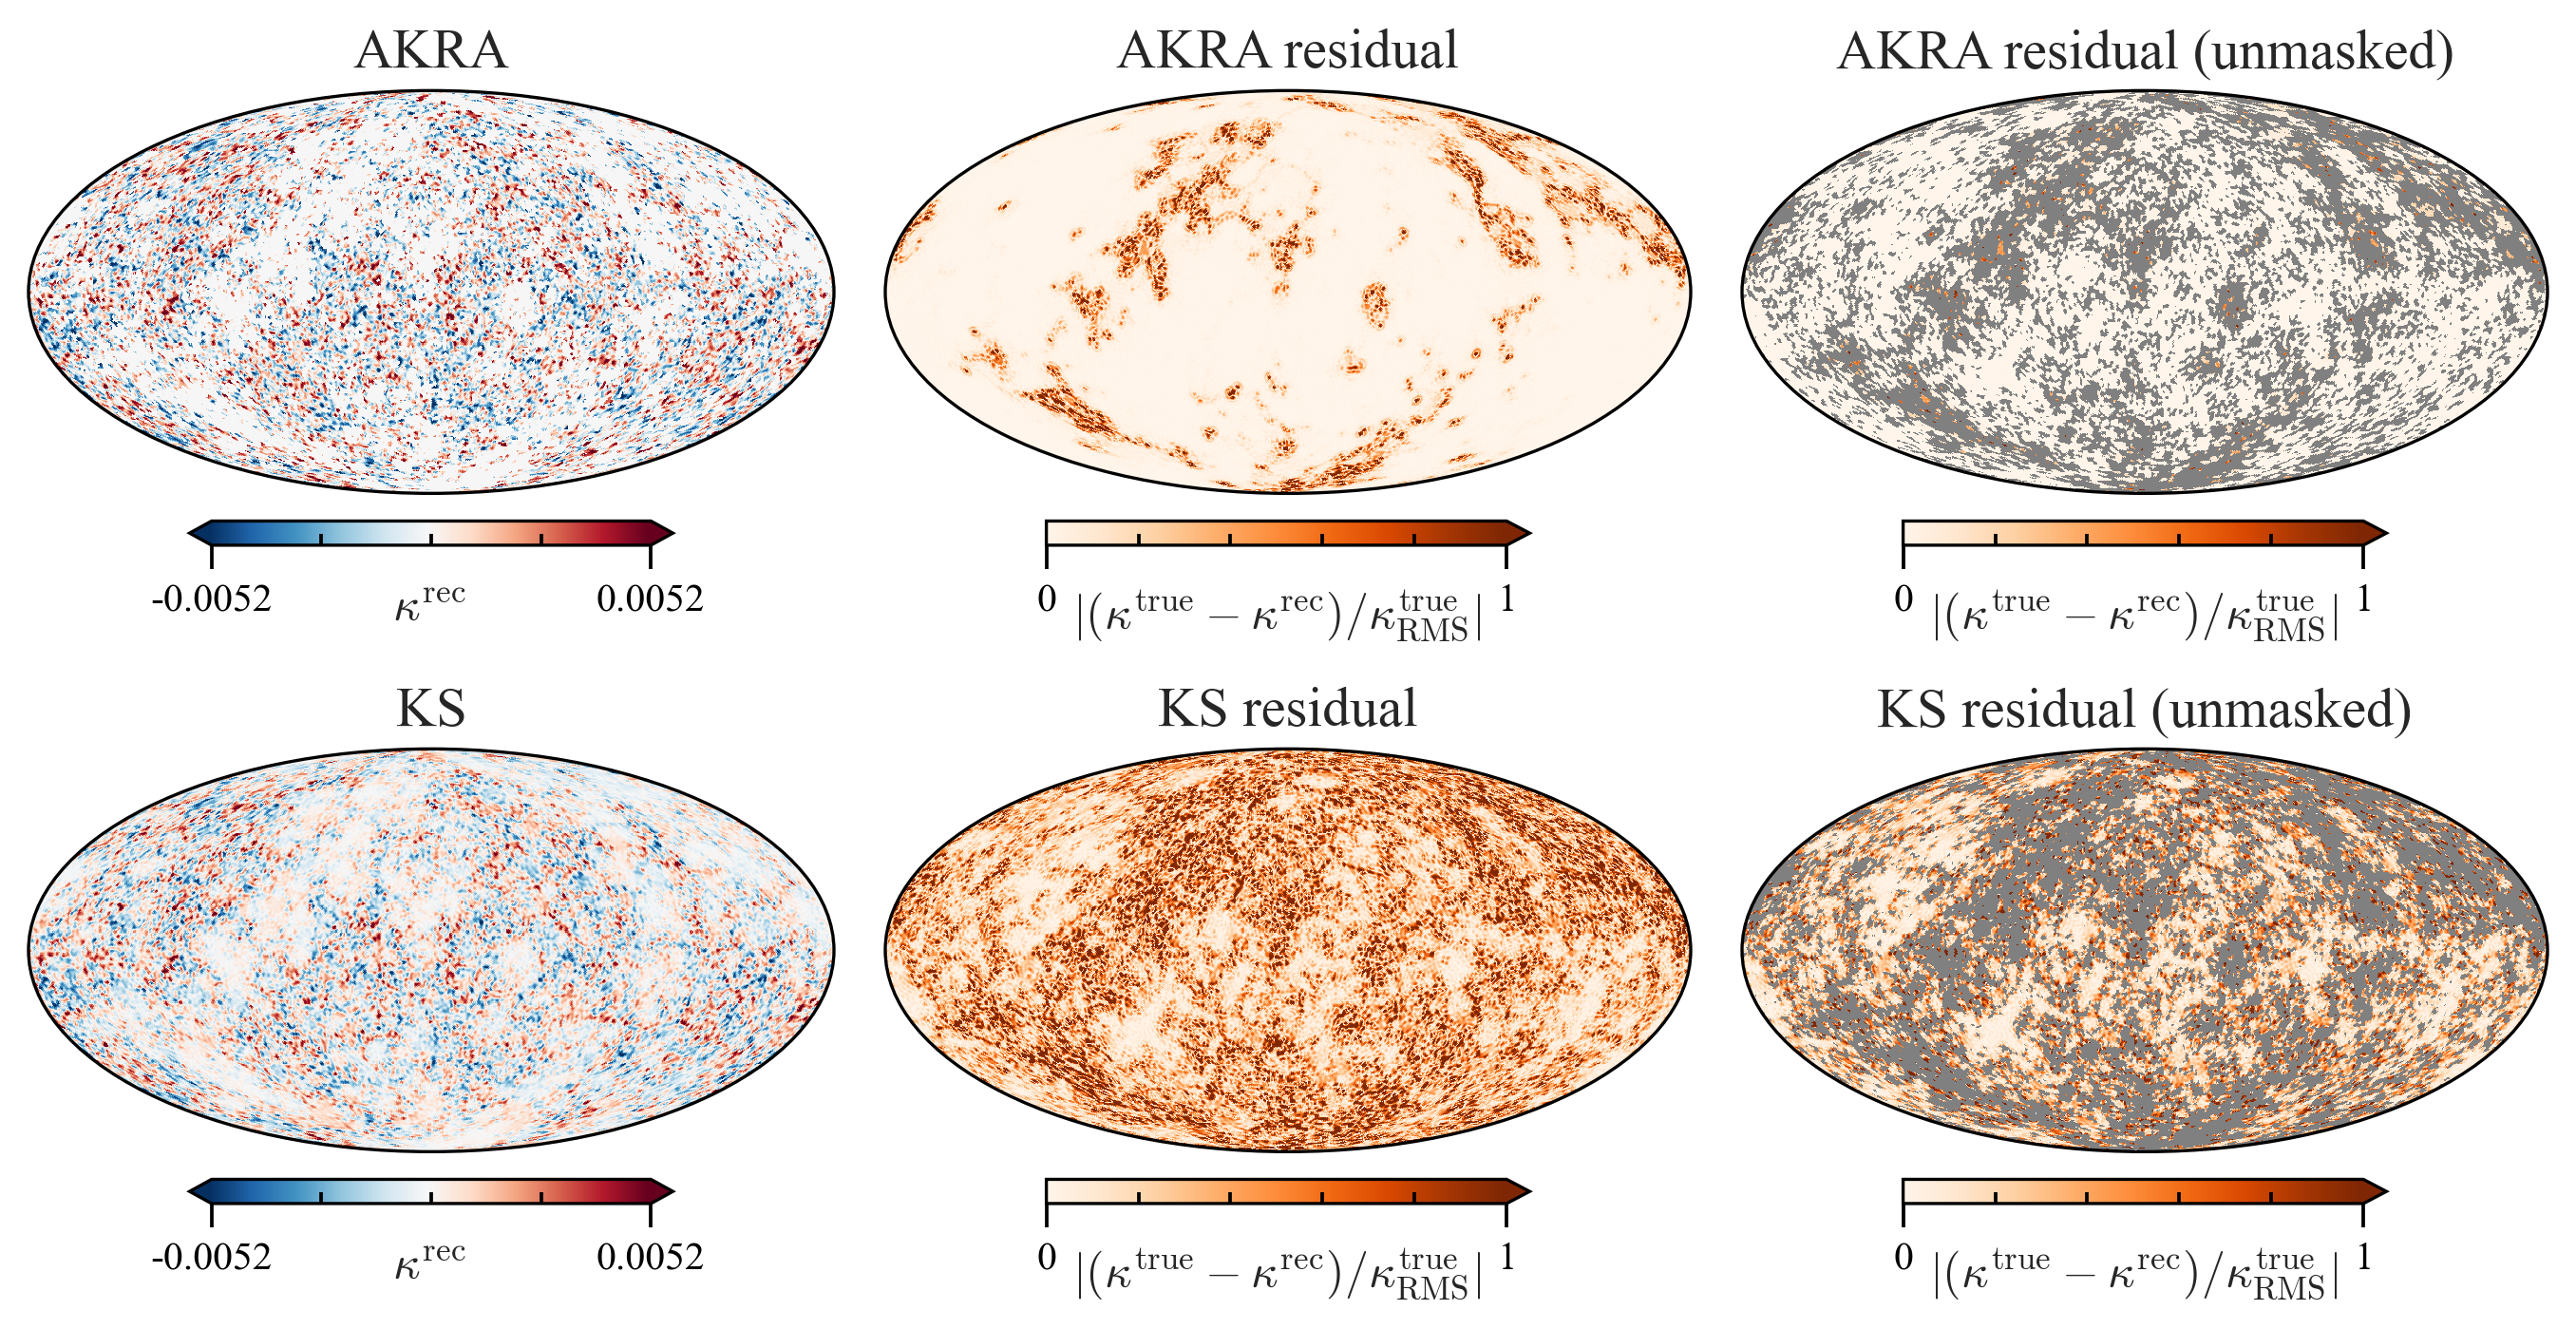

In [11]:
#### Results from AKRA 3.0 and KS methods
plt.figure(figsize=(9.2,4.8), dpi=300)
vmin = -0.0052
vmax = 0.0052

akra_map = akra3_map
mollview(akra_map*mask, sub=231, title="AKRA", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(akra_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=232, vmin=0, vmax=1, title="AKRA residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(akra_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=233, vmin=0, vmax=1, title="AKRA residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)

mollview(ks_map, sub=234, title="KS", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(ks_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=235, vmin=0, vmax=1, title="KS residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(ks_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=236, vmin=0, vmax=1, title="KS residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)
# plt.subplots_adjust(hspace=0.01)
# plt.savefig(figDir + "random_g1g2Mask-results.pdf", bbox_inches='tight', transparent=True)
plt.show()